In [5]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [6]:
dt_clf = DecisionTreeClassifier(random_state=42)

iris_data = load_iris()

X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target,
                                                    test_size=0.2, random_state=42)

dt_clf.fit(X_train, y_train);

In [7]:
from sklearn.tree import export_graphviz

export_graphviz(dt_clf, out_file="tree.dot", class_names=iris_data.target_names,
                feature_names=iris_data.feature_names, impurity=True, filled=True)

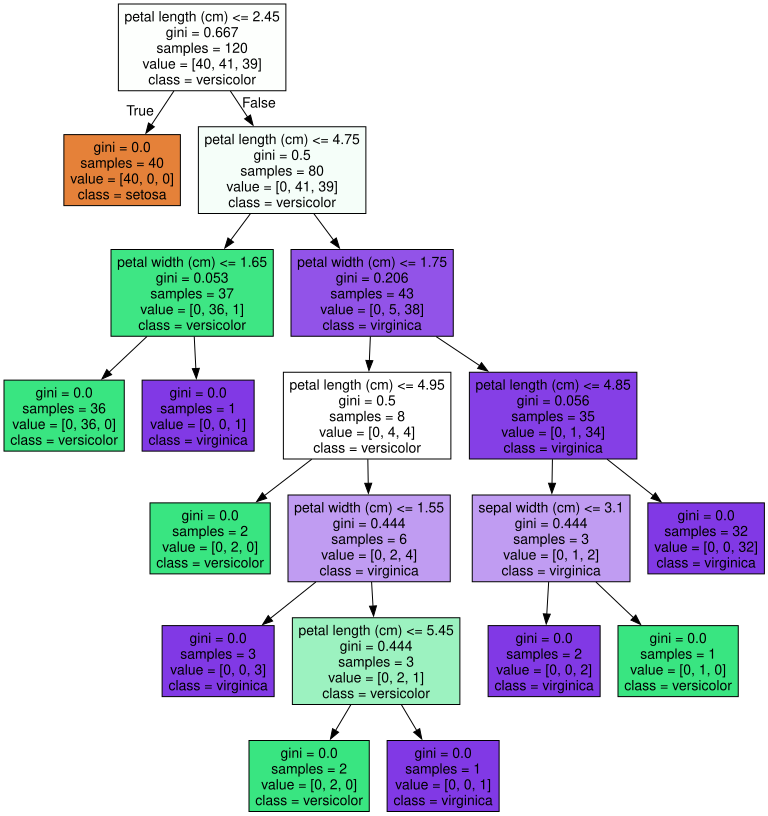

In [8]:
import graphviz

with open("./tree.dot") as f:
    dot_graph = f.read()

graphviz.Source(dot_graph)

Feature Importance: 
[0.    0.017 0.906 0.077]
sepal length (cm): 0.000000
sepal width (cm): 0.016670
petal length (cm): 0.906143
petal width (cm): 0.077186


<Axes: >

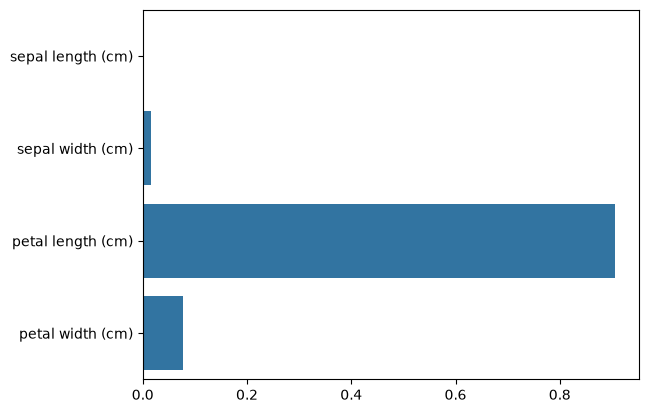

In [9]:
import seaborn as sns
import numpy as np

print("Feature Importance: \n{0}".format(np.round(dt_clf.feature_importances_, 3)))

for name, value in zip(iris_data.feature_names, dt_clf.feature_importances_):
    print("{0}: {1:3f}".format(name, value))

sns.barplot(x=dt_clf.feature_importances_, y=iris_data.feature_names)

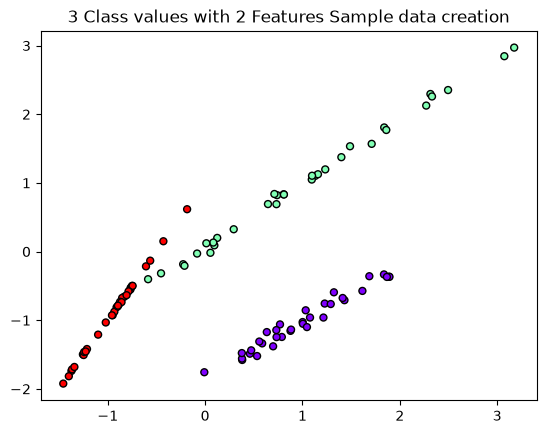

In [10]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

plt.title("3 Class values with 2 Features Sample data creation")

X_features, y_labels = make_classification(n_features=2, n_redundant=0,
                                           n_informative=2, n_classes=3, n_clusters_per_class=1,
                                           random_state=42)

plt.scatter(X_features[:, 0], X_features[:, 1], marker="o", c=y_labels,
            s=25, cmap="rainbow", edgecolor="k")

In [14]:
import numpy as np

def visualize_boundary(model, X, y):
    fig, ax = plt.subplots()

    ax.scatter(X[:, 0], X[:, 1], c=y, s=25, cmap="rainbow", edgecolor="k", clim=(y.min(), y.max()), zorder=3)
    ax.axis("tight")
    ax.axis("off")

    xlim_start, xlim_end = ax.get_xlim()
    ylim_start, ylim_end = ax.get_ylim()

    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(xlim_start, xlim_end, num=200),
                         np.linspace(ylim_start, ylim_end, num=200))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3, levels=np.arange(n_classes+1)-0.5,
                           cmap="rainbow", clim=(y.min(), y.max()), zorder=1)

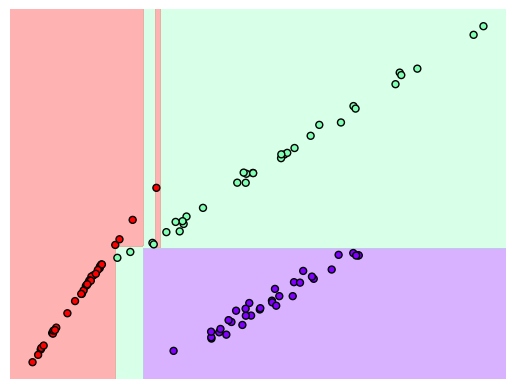

In [15]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(random_state=42).fit(X_features, y_labels)
visualize_boundary(dt_clf, X_features, y_labels)

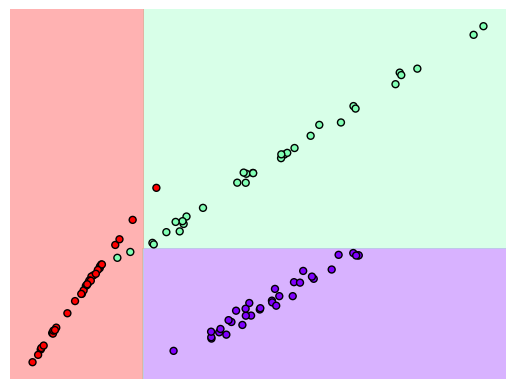

In [16]:
dt_clf = DecisionTreeClassifier(random_state=42, min_samples_leaf=6).fit(X_features, y_labels)
visualize_boundary(dt_clf, X_features, y_labels)